In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance.csv')

# EDA

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
df.shape

(1338, 7)

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

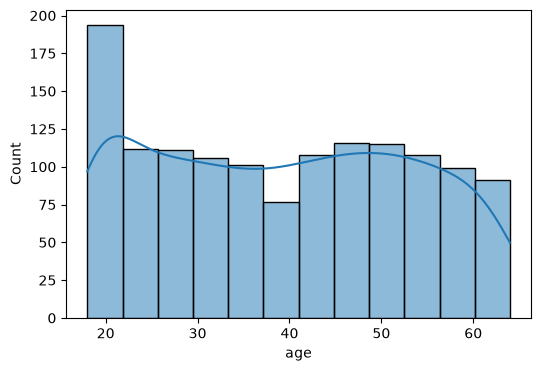

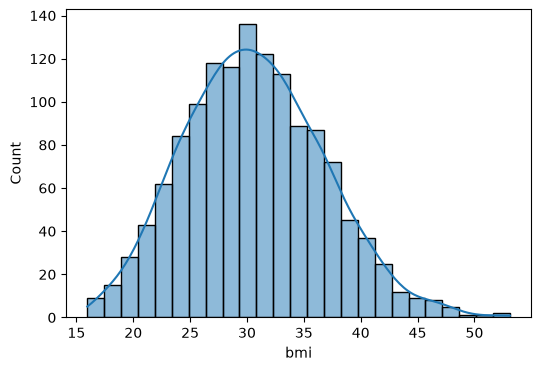

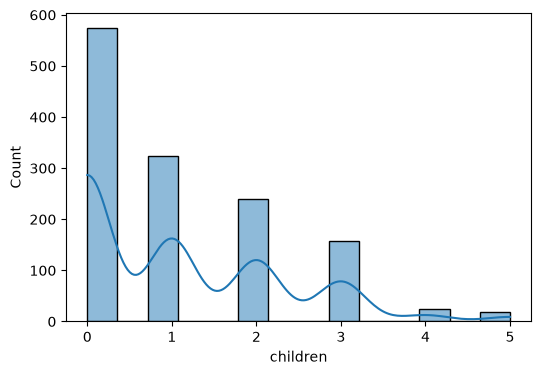

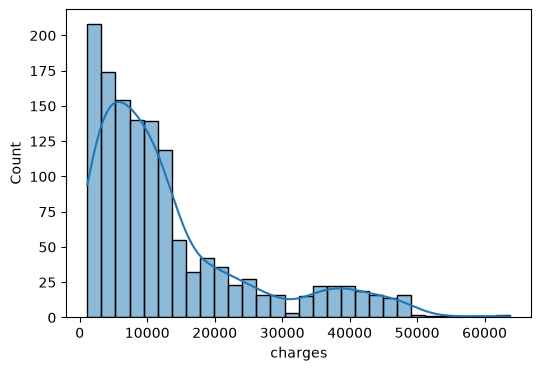

In [9]:
number_column= ['age', 'bmi', 'children', 'charges']
for col in number_column:
    plt.figure(figsize= (6,4))
    sns.histplot(df[col],kde=True)

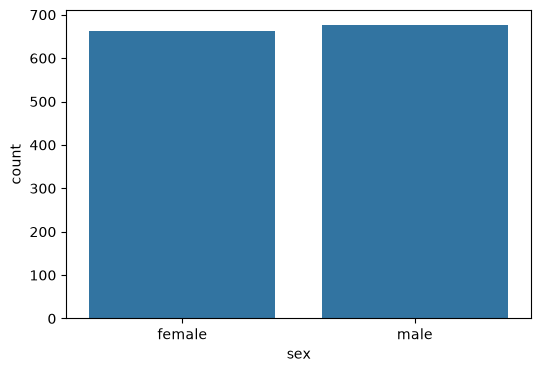

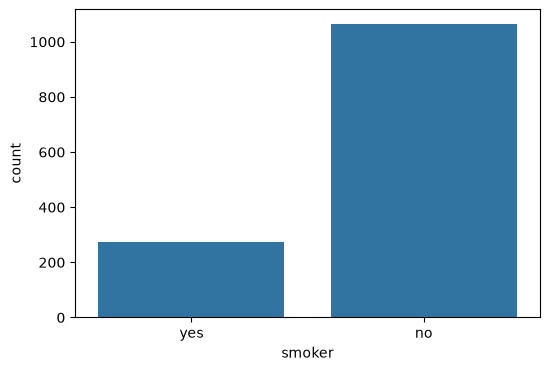

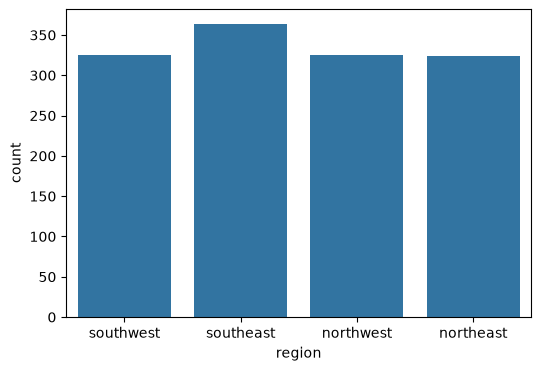

In [10]:
count_column=['sex', 'smoker', 'region']
for col in count_column:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])

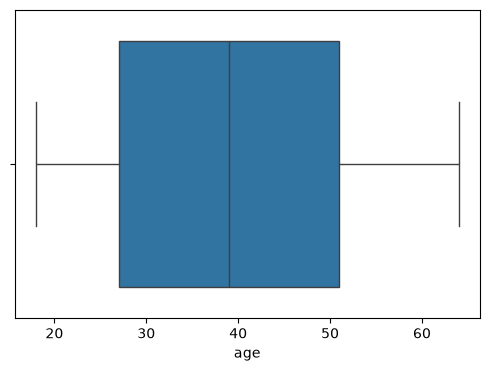

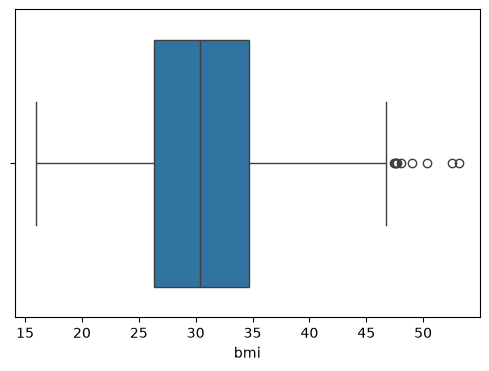

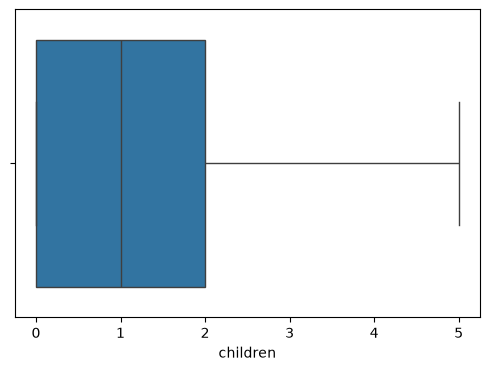

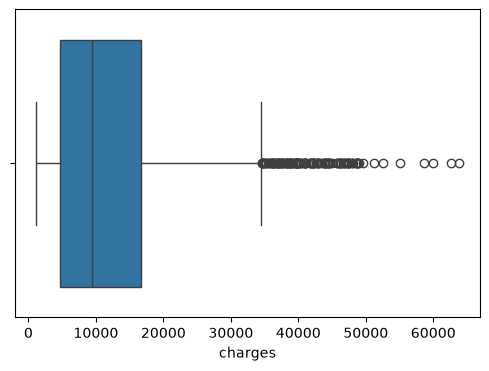

In [11]:
for col in number_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

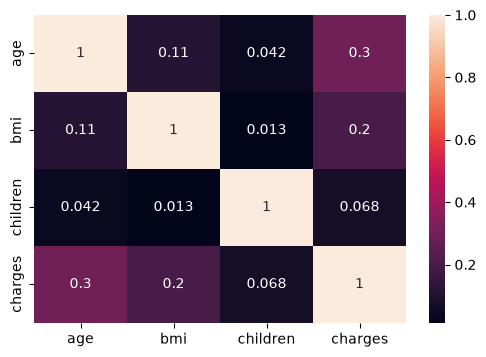

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning & Data preprocessing

In [13]:
df_new=df.copy()
df_new.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [14]:
df_new.shape

(1338, 7)

In [15]:
df_new.drop_duplicates(inplace=True)

In [16]:
df_new.shape

(1337, 7)

In [17]:
df_new.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df_new.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [19]:
df_new['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [20]:
df_new['sex']=df_new['sex'].map({'male':0,'female':1})

In [21]:
df_new.rename(columns={
    'sex':'is_female'
},inplace=True)
df_new.head()

,age,is_female,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [22]:
df_new['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [23]:
df_new['smoker']=df_new['smoker'].map({'no':0,'yes':1})

In [24]:
df_new.rename(columns={
    'smoker':'is_smoker'
},inplace=True)
df_new.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [25]:
df_new['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [26]:
df_new=pd.get_dummies(df_new,columns=['region'])

In [27]:
df_new=df_new.astype(int)

In [28]:
df_new.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0


# Standardization

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
col=['age','bmi','children']
df_new[col]=scaler.fit_transform(df_new[col])

In [30]:
df_new.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0


# Train Test Split

In [31]:
from sklearn.model_selection import train_test_split
X=df_new.drop('charges',axis=1)
y=df_new['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# linear Regression

In [32]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[3487.43, 101.06,1944.13,..., 91.68,-372.52,-198. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['age','is_female','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8423
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [33]:
y_pred= model.predict(X_test)
y_pred

array([ 8.14972341e+03,  5.69649632e+03,  1.44111591e+04,  3.17936989e+04,
        8.97864609e+03,  1.31323257e+04,  3.03955845e+04,  1.50226123e+03,
        1.05731649e+04,  1.12718808e+04,  1.05268512e+04,  3.31832814e+04,
        3.10427479e+04,  1.75436859e+04,  1.09247114e+04,  9.45414172e+03,
        4.29787523e+03,  3.18203651e+04,  3.14600635e+03,  5.18939784e+03,
        3.68999379e+03,  3.04480094e+04,  1.48217633e+04,  3.05163901e+04,
        3.11059800e+04,  5.47145351e+03,  3.55346792e+04,  3.64692429e+04,
        1.13266098e+04,  1.41687845e+04,  6.63850506e+03,  1.28463091e+04,
        4.49791527e+02,  1.20797619e+04,  3.96704534e+04,  1.24172801e+04,
        4.69985948e+03,  3.79411216e+03,  3.07437673e+04,  9.09466885e+03,
        6.94422433e+03,  3.02809631e+04,  3.46280753e+04,  1.23577111e+04,
        7.23422399e+03,  3.31038714e+03,  6.26826462e+03,  8.84163888e+03,
        4.13449196e+03,  9.05986734e+03,  6.74611260e+03,  1.20191286e+04,
        3.13349107e+04,  

In [38]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

# R2 & Adjusted R2

In [34]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)

In [35]:
print('R2 Score:',r2)

R2 Score: 0.8069435680345953


In [36]:
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

In [37]:
print('Adjusted R2:',adj_r2)

Adjusted R2: 0.8002090413381278
